In this notebook we train an ordinary VAE, a Stein Global VAE and a STEIN Hierarchical VAE on the toy dataset of two blobs


In [1]:
%load_ext autoreload
%autoreload 2

from sklearn.datasets import make_blobs
from utils import *
from jax.example_libraries import stax
from numpyro import optim
from CustomModules.architectures import *
from CustomModules.normalizing_flow import normalizing_flow

import pickle
import os

import jax
import jax.numpy as jnp

# Jax psuedo random keys


In [2]:

# For reproducibility, we define a deterministic hashing function for our random keys
# Each unique string will correspond to a unique random independent key, but the same string will always yield the same key.
key_for = make_key_for(jax.random.key(0))

E0529 16:22:19.070730   81388 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0529 16:22:19.080240   81280 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


# Data

In [3]:
blobs, _=  make_blobs(centers=2,n_features=3, cluster_std=0.5, random_state=0, n_samples=2000)

X_train = blobs[:1000]
train_size = X_train.shape[0]
train_loader = [X_train] # No need for batching in this simple dataset
X_test = blobs[1000:]
test_size = X_test.shape[0]

plot3d([(blobs, "Blob Data"),], title="3D Blob Data")

# Define Model Architectures

## Networks

In [4]:

def encoder(hidden_dim, z_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(z_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(z_dim, W_init=stax.randn()), stax.Exp),
        ),
    )


def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(out_dim, W_init=stax.randn()),
    )

def f_shared(hidden_dim, f_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
    )

def g(z_dim, variance_floor=0.1):
    SafeSoftplus = stax.elementwise(lambda x: jnp.clip(stax.softplus(x-3.0), min=0.0, max=20.0) + variance_floor)
    return stax.serial(
        stax.FanOut(2),
        stax.parallel(
            stax.serial(stax.Dense(z_dim), stax.elementwise(lambda x: jnp.clip(x, -10.0, 10.0))),
            stax.serial(stax.Dense(z_dim), SafeSoftplus),
        )
    )

def h(hidden_dim, h_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
    )




## Hyper parameters

In [5]:
num_epochs = 20000 # We train for 20000 epochs to get insight into the convergence of the Stein norms.
hidden_dim = 8
z_dim = 2
lr=5e-4
adam = optim.Adam(lr)
out_dim = blobs.reshape(blobs.shape[0], -1).shape[1]

encoder_args = {"hidden_dim": hidden_dim, "z_dim": z_dim}
decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}

f_args = {"hidden_dim": hidden_dim, "f_dim": z_dim}
g_args = {"z_dim": z_dim}
h_args = {"hidden_dim": hidden_dim, "h_dim": z_dim}
flow_args = {"input_dim": z_dim, "hidden_dims": [5, 5], "steps": 0, "inv": True} #steps: 0 means flow is deactivated
m_dim = z_dim

hierarchical_layers = 2
num_stein_particles = 4
num_elbo_particles = 10 # Default value of 10. Increasing has been seen to lower variance of stein norms.


## Define models


In [6]:
ordinary_vae = BaseVAE(encoder, encoder_args, decoder, decoder_args, z_dim, normal_scale=0.5)
stein_global_vae = SteinGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim, normal_scale=0.5)
stein_hierarchical_vae = SteinHierarchicalVAE(decoder, decoder_args, f_shared, f_args, h, h_args, g, g_args, g, g_args, hierarchical_layers, z_dim, m_dim, normalizing_flow, flow_args, normal_scale=0.5)


# Training

In [7]:
# Checkpoint names:
checkpoints_dir = "checkpoints_toy_data"
if not os.path.exists(checkpoints_dir):
    os.makedirs(checkpoints_dir)
checkpoint_ordinary = f"{checkpoints_dir}/toy_ordinary_vae_epochs={num_epochs}.pkl"
checkpoint_stein_global = f"{checkpoints_dir}/toy_stein_global_vae_epochs={num_epochs}_stein_particles={num_stein_particles}.pkl"
checkpoint_stein_hierarchical = f"{checkpoints_dir}/toy_stein_hierarchical_vae_epochs={num_epochs}_stein_particles={num_stein_particles}.pkl"



If checkpoint already exists, then just load it, otherwise train. This ensures no wasted time

In [8]:
if os.path.exists(checkpoint_ordinary):
    with open(checkpoint_ordinary, "rb") as f:
        ordinary_vae = pickle.load(f)
    print("Loaded Ordinary VAE from checkpoint.")
else:
    ordinary_vae.train(train_loader, train_size, adam, num_epochs,  key_for("ordinary_vae_training"))
    with open(checkpoint_ordinary, "wb") as f:
        pickle.dump(ordinary_vae, f)
    print("Trained and saved Ordinary VAE.")

Loaded Ordinary VAE from checkpoint.


In [9]:
if os.path.exists(checkpoint_stein_global):
    with open(checkpoint_stein_global, "rb") as f:
        stein_global_vae, stein_global_vae_norms = pickle.load(f)
    print("Loaded Stein Global VAE from checkpoint.")
else:
    stein_global_vae_norms = stein_global_vae.train(train_loader, train_size, adam, num_epochs, key_for("stein_global_vae_training"), num_stein_particles, num_elbo_particles=num_elbo_particles)
    with open(checkpoint_stein_global, "wb") as f:
        pickle.dump((stein_global_vae, stein_global_vae_norms), f)
    print("Trained and saved Stein Global VAE.")

Loaded Stein Global VAE from checkpoint.


In [10]:
if os.path.exists(checkpoint_stein_hierarchical):
    with open(checkpoint_stein_hierarchical, "rb") as f:
        stein_hierarchical_vae, stein_hierarchical_vae_norms = pickle.load(f)
    print("Loaded Stein Hierarchical VAE from checkpoint.")
else:
    stein_hierarchical_vae_norms = stein_hierarchical_vae.train(train_loader, train_size, adam, num_epochs, key_for("stein_hierarchical_vae_training"), num_stein_particles, num_elbo_particles=num_elbo_particles)
    with open(checkpoint_stein_hierarchical, "wb") as f:
        pickle.dump((stein_hierarchical_vae, stein_hierarchical_vae_norms), f)
    print("Trained and saved Stein Hierarchical VAE.")


Loaded Stein Hierarchical VAE from checkpoint.


# Results

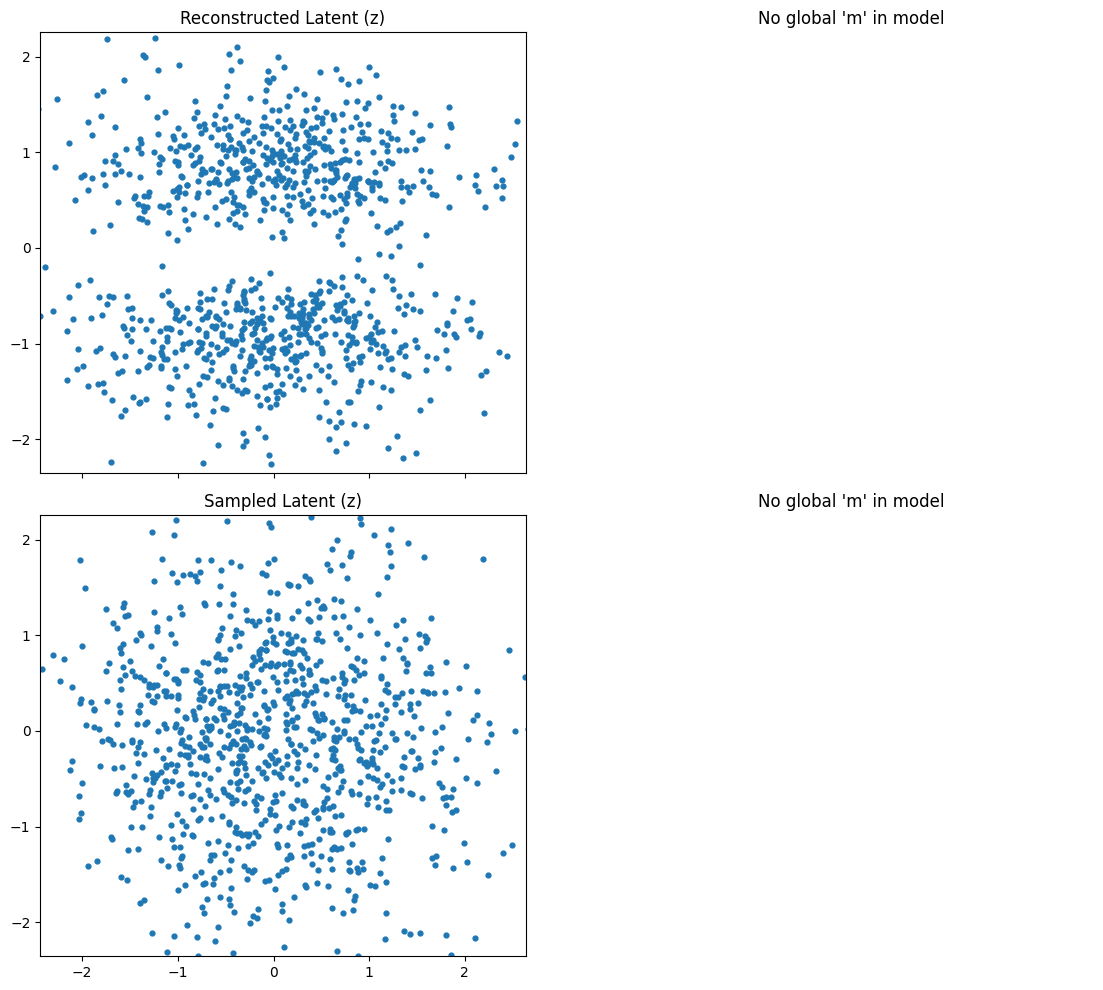

In [11]:
plot_model(ordinary_vae, key_for("ordinary_vae_plotting"), X_test)

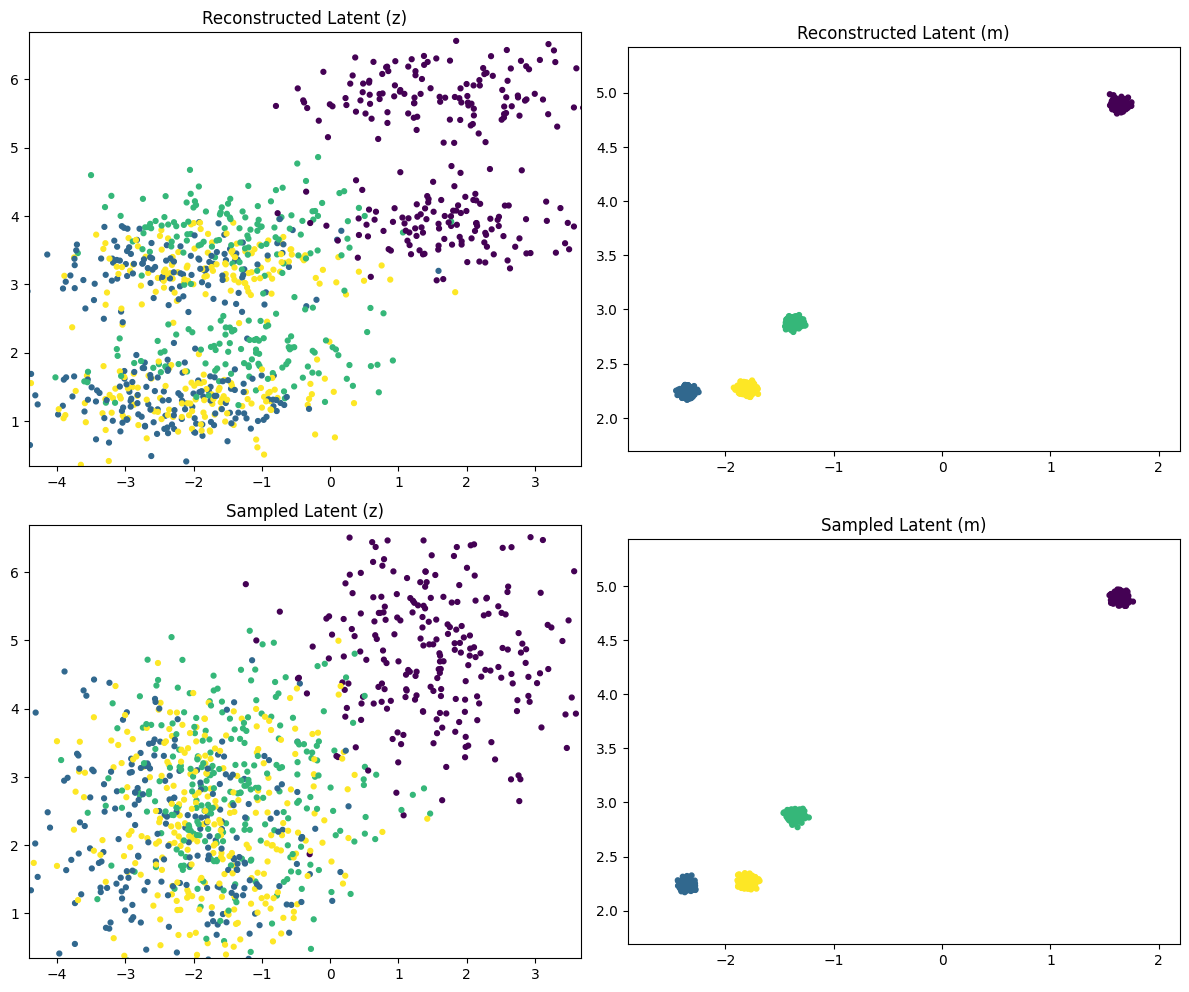

In [12]:
plot_model(stein_global_vae, key_for("stein_global_vae_plotting"), X_test, share_axis=False)

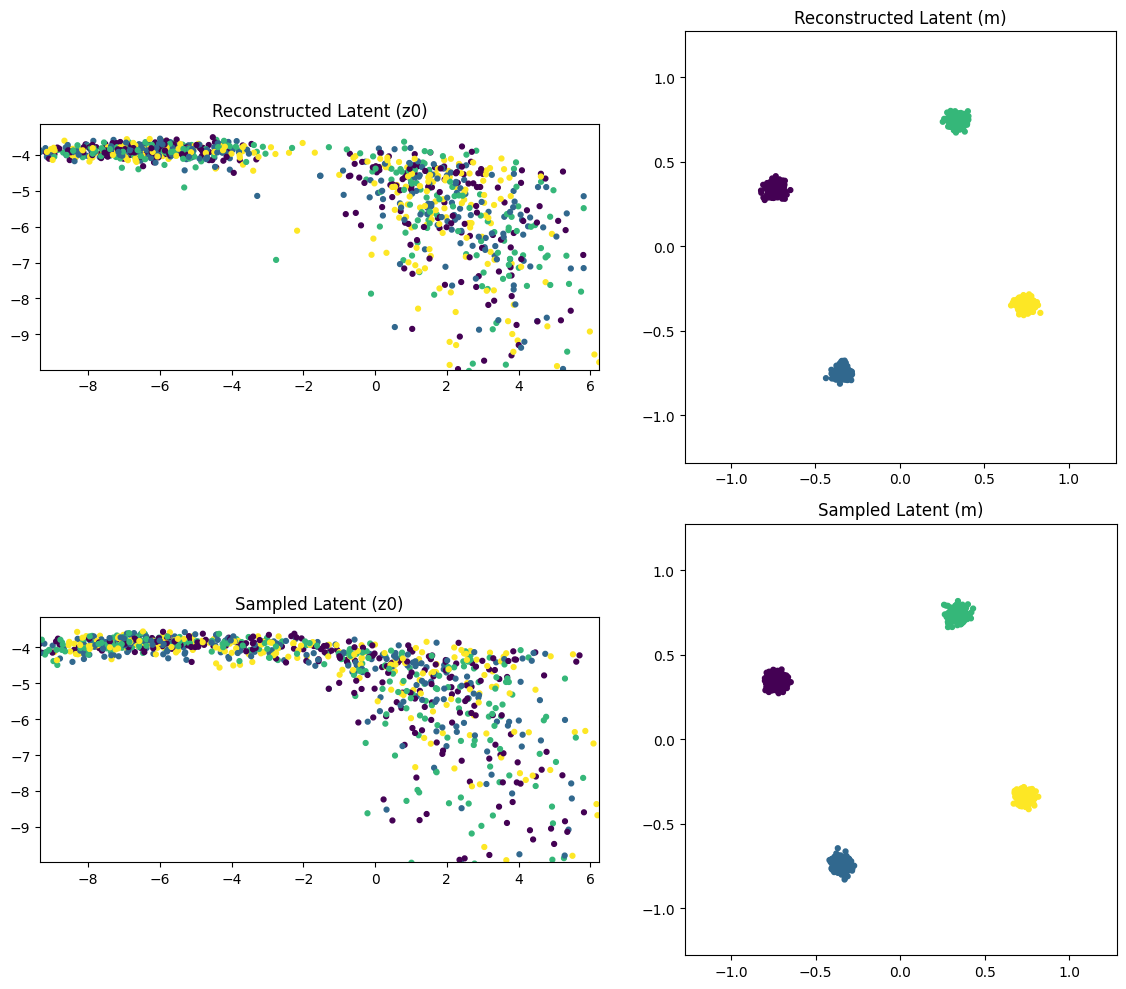

In [13]:
plot_model(stein_hierarchical_vae, key_for("stein_hierarchical_vae_plotting"), X_test, share_axis=False)

## Convergence testing

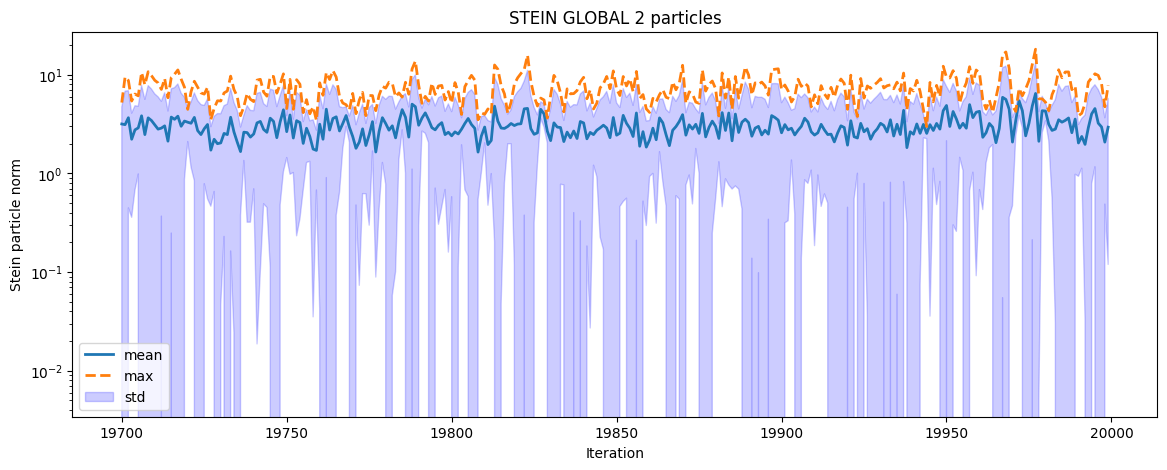

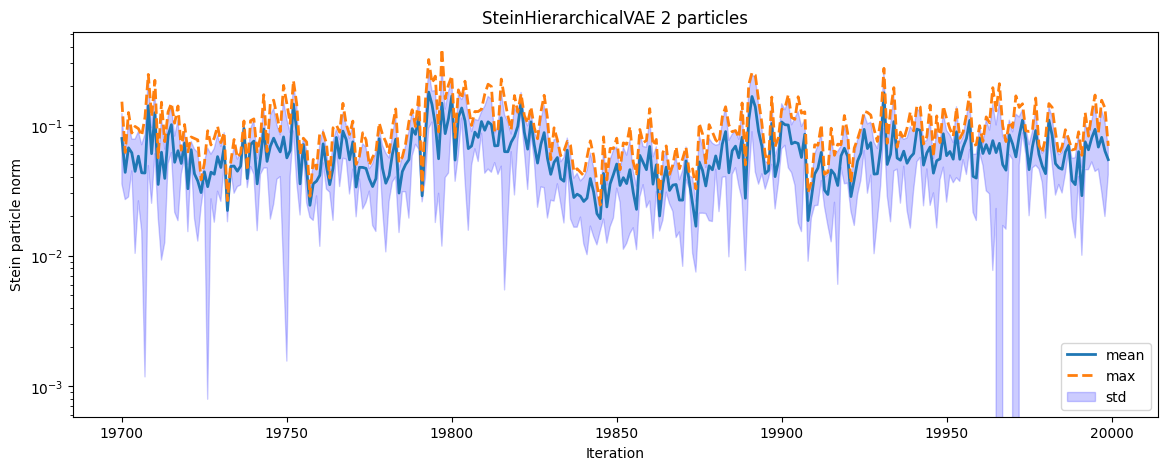

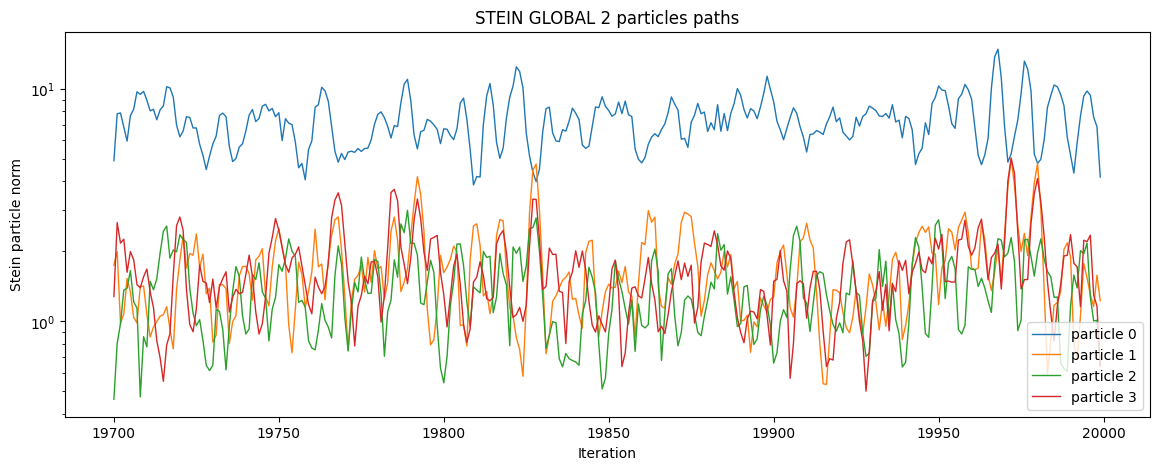

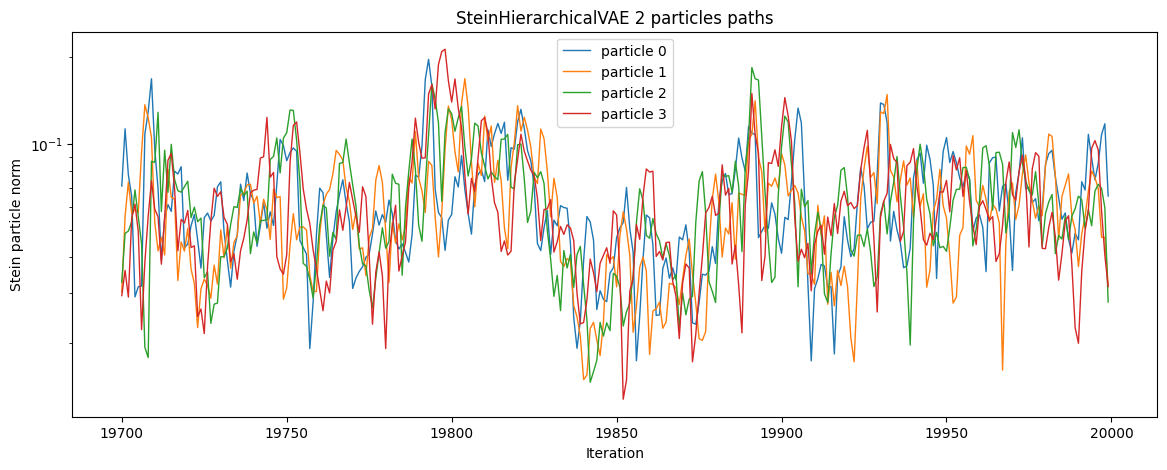

In [14]:
stein_global_stats = plot_stein_norms(stein_global_vae_norms, "STEIN GLOBAL 2 particles", slice(num_epochs-300, num_epochs))
stein_hierarchical_stats = plot_stein_norms(stein_hierarchical_vae_norms, "SteinHierarchicalVAE 2 particles", slice(num_epochs-300, num_epochs))
stein_global_paths = plot_individual_norm_paths(stein_global_vae_norms, "STEIN GLOBAL 2 particles paths", slice(num_epochs-300, num_epochs))
stein_hierarchical_paths = plot_individual_norm_paths(stein_hierarchical_vae_norms, "SteinHierarchicalVAE 2 particles paths", slice(num_epochs-300, num_epochs))

Full paths

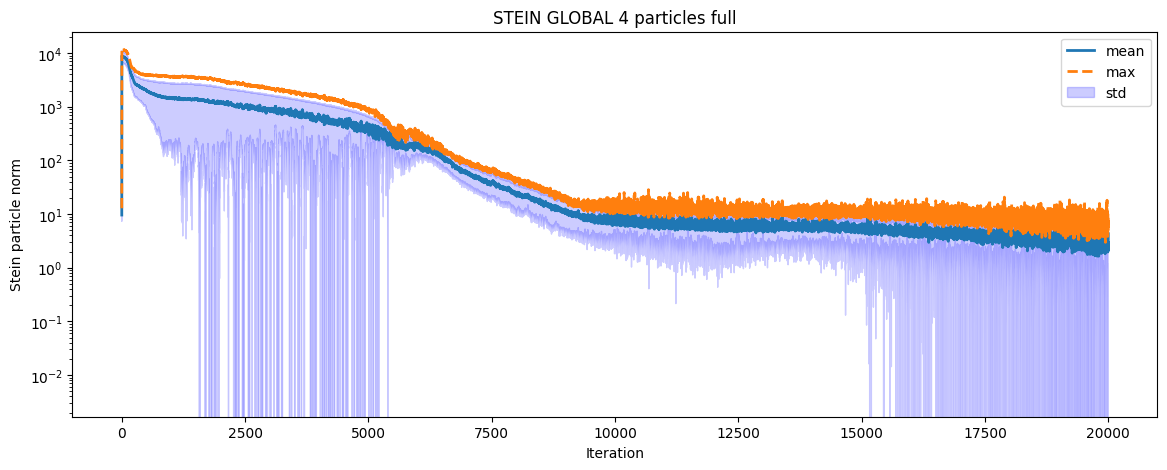

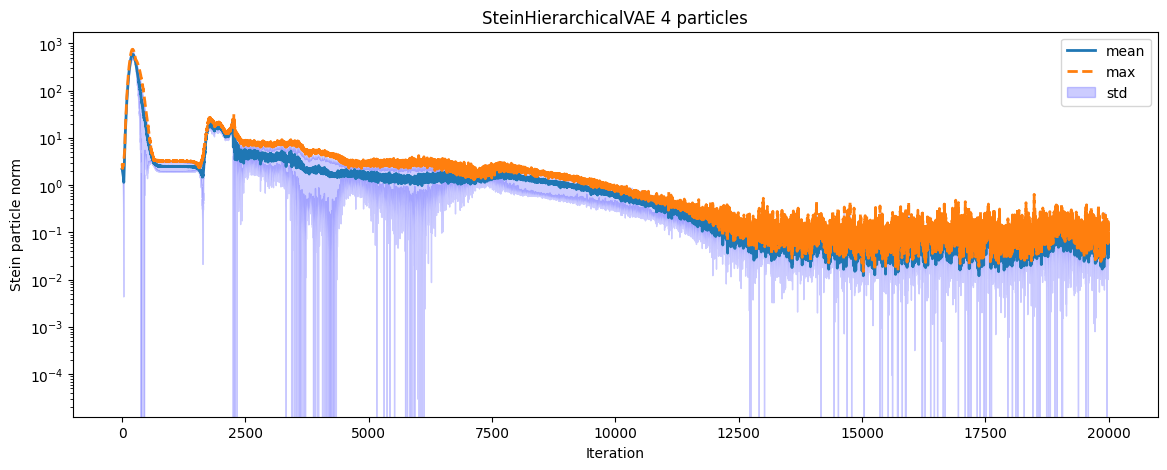

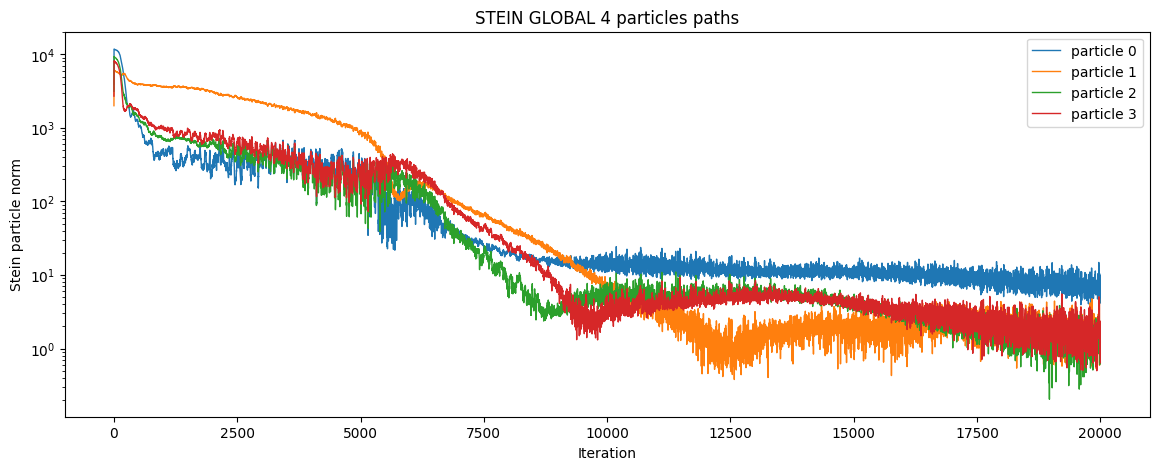

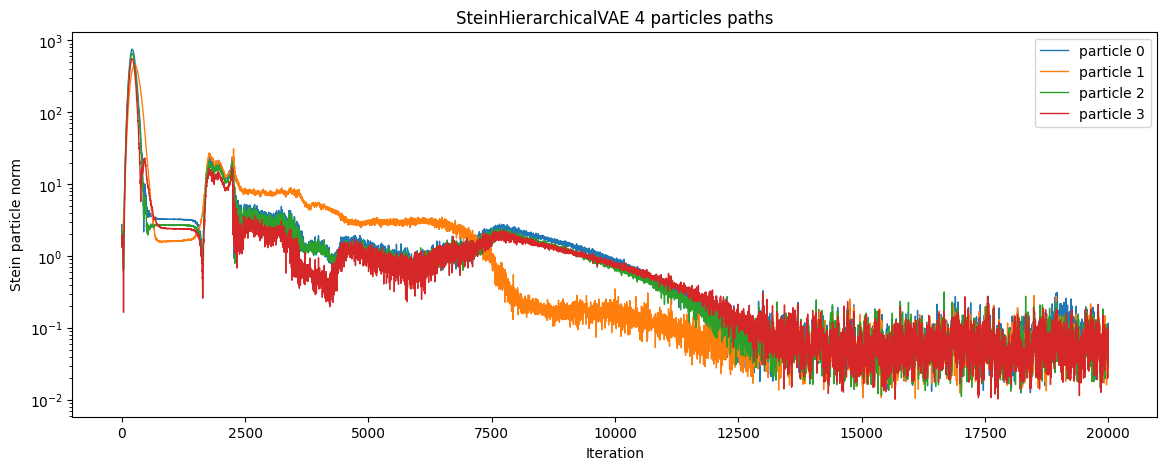

In [15]:
stein_global_stats = plot_stein_norms(stein_global_vae_norms, "STEIN GLOBAL 4 particles full", slice(0, 10000000))
stein_hierarchical_stats = plot_stein_norms(stein_hierarchical_vae_norms, "SteinHierarchicalVAE 4 particles", slice(0, 10000000))
stein_global_paths = plot_individual_norm_paths(stein_global_vae_norms, "STEIN GLOBAL 4 particles paths", slice(0, 10000000))
stein_hierarchical_paths = plot_individual_norm_paths(stein_hierarchical_vae_norms, "SteinHierarchicalVAE 4 particles paths", slice(0, 10000000))